In [1]:
!pip install pyarrow
import pandas as pd
import numpy as np


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\talic\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import os

CSV = "Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv"
PARQUET = "medicare_2024.parquet"

if os.path.exists(PARQUET):
    data = pd.read_parquet(PARQUET)         
else:
    data = pd.read_csv(
        CSV,
        dtype={"Rndrng_NPI": str, "Rndrng_Prvdr_Zip5": str, "Rndrng_Prvdr_State_FIPS": str,
               "HCPCS_Cd": str, "Rndrng_Prvdr_RUCA": str},   
        low_memory=False,
    )
    
    for col in data.select_dtypes("object"):
        if data[col].nunique() < 1000:
            data[col] = data[col].astype("category")
    data.to_parquet(PARQUET, index=False)    

print(data.shape)

(9781673, 28)


In [3]:
data.to_parquet(PARQUET, index=False)
print("saved")

saved


In [4]:
print("Shape:", data.shape)
print(f"Memory: {data.memory_usage(deep=True).sum() / 1e9:.2f} GB")

overview = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "n_unique": data.nunique(),
    "n_missing": data.isna().sum(),
    "pct_missing": (data.isna().mean() * 100).round(2),
    "example": data.iloc[0],
})
overview

Shape: (9781673, 28)
Memory: 6.71 GB


,dtype,n_unique,n_missing,pct_missing,example
Rndrng_NPI,object,1207473,0,0.00,1003000126
Rndrng_Prvdr_Last_Org_Name,object,290816,0,0.00,Enkeshafi
Rndrng_Prvdr_First_Name,object,84734,474867,4.85,Ardalan
Rndrng_Prvdr_MI,category,32,3465045,35.42,NaN
Rndrng_Prvdr_Crdntls,object,18018,1079707,11.04,M.D.
Rndrng_Prvdr_Ent_Cd,category,2,0,0.00,I
Rndrng_Prvdr_St1,object,425655,0,0.00,6410 Rockledge Dr Ste 304
Rndrng_Prvdr_St2,object,51376,7637996,78.08,NaN
Rndrng_Prvdr_City,object,12736,0,0.00,Bethesda
Rndrng_Prvdr_State_Abrvtn,category,62,0,0.00,MD


In [5]:
data.sample(5, random_state=42).T

,6210378,8376089,5153263,8306105,8478171
Rndrng_NPI,1639241136,1851578660,1528297744,1841735339,1861664377
Rndrng_Prvdr_Last_Org_Name,Kammula,Mosovich,Szpak,Fleitas,Thomas
Rndrng_Prvdr_First_Name,Suvarnarekha,Jonathan,Jessica,Lisa,Crystal
Rndrng_Prvdr_MI,A,NaN,A,NaN,R
Rndrng_Prvdr_Crdntls,MD,M.D.,PA-C,N.P.,PT
Rndrng_Prvdr_Ent_Cd,I,I,I,I,I
Rndrng_Prvdr_St1,10215 Fernwood Rd Ste 100,22 Old Waterbury Rd,700 S Park St Ste A,1105 Earl Frye Blvd,144 W Los Angeles Ave
Rndrng_Prvdr_St2,NaN,Suite 201,NaN,NaN,Ste 110
Rndrng_Prvdr_City,Bethesda,Southbury,Madison,Amory,Moorpark
Rndrng_Prvdr_State_Abrvtn,MD,CT,WI,MS,CA


In [6]:
num_cols = ["Tot_Benes", "Tot_Srvcs", "Tot_Bene_Day_Srvcs", "Avg_Sbmtd_Chrg",
            "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt", "Avg_Mdcr_Stdzd_Amt"]

data[num_cols].describe(percentiles=[.01, .25, .5, .75, .99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
Tot_Benes,9781673.0,84.987427,1312.172007,11.000000,11.000000,17.000000,32.000000,72.000000,601.000000,8.967620e+05
Tot_Srvcs,9781673.0,281.819252,6307.907761,4.400000,11.000000,21.000000,43.000000,119.000000,2753.000000,6.486401e+06
Tot_Bene_Day_Srvcs,9781673.0,137.257892,2181.446684,11.000000,11.000000,20.000000,41.000000,106.000000,1180.000000,1.835261e+06
Avg_Sbmtd_Chrg,9781673.0,430.762116,1521.585295,0.000035,5.000000,73.281250,180.000000,367.000000,4293.000000,9.999999e+04
Avg_Mdcr_Alowd_Amt,9781673.0,106.367968,332.987671,0.000000,0.688503,25.485379,71.551080,121.138800,825.994244,5.396543e+04
Avg_Mdcr_Pymt_Amt,9781673.0,83.004780,265.616171,0.000000,0.520885,19.650000,52.456515,90.912222,656.382252,4.299489e+04
Avg_Mdcr_Stdzd_Amt,9781673.0,82.494639,267.158653,0.000000,0.527639,19.471133,52.655000,90.776290,652.097869,4.299489e+04


### Consistency checks
Checking whether missing values/extra unique values are errors or expected:
- Missing first names. Are these just organizations (`Ent_Cd = O`)?
- 25 countries, 62 state codes. Find foreign providers and territories
- Missing FIPS / RUCA. We will drop FIPS  and RUCA missing for 5,291 rows (0.05%) we will label it as "unknown"
- One description per HCPCS code? Needed for the Power BI procedure table

In [ ]:
#Missing first names: are they organizations (Ent_Cd = "O")?
print(pd.crosstab(data["Rndrng_Prvdr_Ent_Cd"], data["Rndrng_Prvdr_First_Name"].isna()), "\n")

#Countries and states outside the 50 states + DC
print(data["Rndrng_Prvdr_Cntry"].value_counts().head(10), "\n")
states = set("AL AK AZ AR CA CO CT DE DC FL GA HI ID IL IN IA KS KY LA ME MD MA MI MN MS MO MT NE NV NH NJ NM NY NC ND OH OK OR PA RI SC SD TN TX UT VT VA WA WV WI WY".split())
other = data.loc[~data["Rndrng_Prvdr_State_Abrvtn"].astype(str).isin(states), "Rndrng_Prvdr_State_Abrvtn"]
print(other.value_counts().head(15), "\n")

#Does each HCPCS code have exactly one description?
print("max descriptions per code:", data.groupby("HCPCS_Cd")["HCPCS_Desc"].nunique().max())

Rndrng_Prvdr_First_Name    False   True 
Rndrng_Prvdr_Ent_Cd                     
I                        9306806      12
O                              0  474855 

Rndrng_Prvdr_Cntry
US    9781251
DE         82
CA         79
IT         44
JP         36
TR         30
AE         26
PK         17
KR         15
IL         14
Name: count, dtype: int64 

Rndrng_Prvdr_State_Abrvtn
PR    15569
GU     1813
VI     1409
AP      536
ZZ      422
AE      292
XX      258
AA      232
MP      132
FM        5
AS        1
AR        0
CA        0
AZ        0
FL        0
Name: count, dtype: int64 

Rndrng_Prvdr_State_Abrvtn  Rndrng_Prvdr_Cntry
FM                         US                    5
Name: count, dtype: int64 

Rndrng_Prvdr_Cntry
US    4984
CA      79
DE      72
AE      24
JP      18
Name: count, dtype: int64 

max descriptions per code: 1


**Notes:**
- Missing first names = organizations (all 474,855 `O` rows). Only 12 individuals missing a first name - ignore
- 422 rows are foreign (state code `ZZ`) - drop
- PR, GU, VI (territories) and AP, AE (military) are real Medicare providers - keep
- Every HCPCS code has exactly 1 description 

### Data quality checks
Looking for duplicates and values that don't make logical sense.

Expected relationships:
- `Benes ≤ Bene_Days` - every patient was seen on at least 1 day
- `Bene_Days ≤ Srvcs` - every patient-day has at least 1 service (one patient can get several units of the same service on one day)
- `Pymt ≤ Alowd` - allowed = Medicare payment + patient's share (deductible/coinsurance), so Medicare can't pay more than allowed

Rows breaking these rules are data errors.

In [16]:
KEY = ["Rndrng_NPI", "HCPCS_Cd", "Place_Of_Srvc"]
drug = data["HCPCS_Drug_Ind"] == "Y"

checks = {
    # duplicates on the row key
    "duplicate NPI x HCPCS x POS":data.duplicated(subset=KEY),
    # volume logic
    "Srvcs < Benes": data["Tot_Srvcs"] < data["Tot_Benes"],
    "Bene_Days > Srvcs": data["Tot_Bene_Day_Srvcs"] > data["Tot_Srvcs"],
    "Bene_Days < Benes": data["Tot_Bene_Day_Srvcs"] < data["Tot_Benes"],
    "non-integer Srvcs (non-drug)":  ((data["Tot_Srvcs"] % 1) != 0) & ~drug,
    # money logic
    "Pymt > Alowd": data["Avg_Mdcr_Pymt_Amt"] > data["Avg_Mdcr_Alowd_Amt"] + 0.01,
    "Alowd == 0": data["Avg_Mdcr_Alowd_Amt"] == 0,
    "Pymt == 0": data["Avg_Mdcr_Pymt_Amt"] == 0,
    "Sbmtd >= 99,999 (possible cap)": data["Avg_Sbmtd_Chrg"] >= 99999,
}

dq = pd.DataFrame({"n_rows": {k: int(v.sum()) for k, v in checks.items()}})
dq["pct"] = (dq["n_rows"] / len(data) * 100).round(4)
dq

,n_rows,pct
duplicate NPI x HCPCS x POS,0,0.0000
Srvcs < Benes,34,0.0003
Bene_Days > Srvcs,72,0.0007
Bene_Days < Benes,0,0.0000
non-integer Srvcs (non-drug),8298,0.0848
Pymt > Alowd,0,0.0000
Alowd == 0,18,0.0002
Pymt == 0,94,0.0010
"Sbmtd >= 99,999 (possible cap)",28,0.0003


**Notes:**
- No duplicate keys, so NPI × HCPCS × POS is the unique row ID
- Bene_Days < Benes = 0 and Pymt > Alowd = 0 - columns behave as expected 
- Srvcs < Benes (34), Bene_Days > Srvcs (72), Alowd = 0 (18) - impossible values, drop (90 rows total, some overlap)
- 8,298 non-drug rows have fractional services - checked below
- Pymt = 0 (94) and charge ≥ $99,999 (28) - unusual but not errors, keep

In [17]:
# Which non-drug codes have fractional service counts?
frac = (data["Tot_Srvcs"] % 1 != 0) & (data["HCPCS_Drug_Ind"] == "N")
top = data.loc[frac, "HCPCS_Cd"].value_counts().head(10).to_frame("n_rows")
top["desc"] = top.index.map(data.drop_duplicates("HCPCS_Cd").set_index("HCPCS_Cd")["HCPCS_Desc"]).str[:60]
top

,n_rows,desc
HCPCS_Cd,,
A0425,7668,"Ground mileage, per statute mile"
A0436,308,"Rotary wing air mileage, per statute mile"
P9603,70,Travel allowance one way in connection with me...
A0435,62,"Fixed wing air mileage, per statute mile"
88341,14,Special stained specimen slides to examine tis...
96372,10,Injection of drug or substance under skin or i...
A0428,9,"Ambulance service, basic life support, non-eme..."
77067,8,Screening mammography
99213,8,Established patient office or other outpatient...


**Notes:**
- Almost all are mileage codes (A0425 ground ambulance, A0435/A0436 air ambulance, P9603 lab travel) - Tot_Srvcs = miles, not visits
- The rest are a few rows per code - likely CMS rounding, ignore
- So Tot_Srvcs has 3 different units: visits, drug units, miles - can't sum across codes - add `segment` column

In [10]:
# Unit type of Tot_Srvcs: visits/procedures, drug units, or miles
is_drug = data["HCPCS_Drug_Ind"] == "Y"
is_mileage = data["HCPCS_Desc"].str.contains("mileage|per statute mile|miles actually travel",
                                             case=False, na=False)

data["segment"] = np.select([is_drug, is_mileage], ["drug", "mileage"], default="service")
data["segment"] = data["segment"].astype("category")

print(data["segment"].value_counts())
# Check which codes were classified as mileage
print(data.loc[data["segment"] == "mileage", ["HCPCS_Cd", "HCPCS_Desc"]].drop_duplicates())

segment
service    9242364
drug        529613
mileage       9696
Name: count, dtype: int64
       HCPCS_Cd                                         HCPCS_Desc
641       A0425                   Ground mileage, per statute mile
11910     A0436          Rotary wing air mileage, per statute mile
55375     P9603  Travel allowance one way in connection with me...
162686    A0435           Fixed wing air mileage, per statute mile


**Notes:**
- service 9,242,364 / drug 529,613 / mileage 9,696
- Mileage = exactly the 4 transport codes 

### Cleaning
Raw `data` stays untouched, cleaned version goes to `clean`. Each step is logged.

In [19]:
log = []
def log_step(name, before, after):
    log.append({"step": name, "rows_before": before, "rows_after": after,
                "removed": before - after,
                "pct_removed": round((before - after) / before * 100, 4)})

clean = data.copy()

# Keep US providers only (drops foreign addresses, state code "ZZ")
n = len(clean)
clean = clean[clean["Rndrng_Prvdr_Cntry"] == "US"]
log_step("keep US providers only", n, len(clean))

# Drop logically impossible rows and zero allowed amounts
n = len(clean)
bad = ((clean["Tot_Srvcs"] < clean["Tot_Benes"]) |
       (clean["Tot_Bene_Day_Srvcs"] > clean["Tot_Srvcs"]) |
       (clean["Avg_Mdcr_Alowd_Amt"] <= 0))
clean = clean[~bad]
log_step("drop logical inconsistencies / zero allowed", n, len(clean))

# Drop columns not needed for ML or Power BI
drop_cols = ["Rndrng_Prvdr_St1", "Rndrng_Prvdr_St2", "Rndrng_Prvdr_MI",
             "Rndrng_Prvdr_State_FIPS", "Rndrng_Prvdr_Cntry"]
clean = clean.drop(columns=drop_cols)

# Tidy up: reset index, drop unused category levels (e.g. "ZZ")
clean = clean.reset_index(drop=True)
for col in clean.select_dtypes("category"):
    clean[col] = clean[col].cat.remove_unused_categories()

cleaning_log = pd.DataFrame(log)
print(f"Kept {len(clean):,} of {len(data):,} rows ({len(clean) / len(data) * 100:.3f}%)")
print(f"Columns: {data.shape[1]} - {clean.shape[1]}")
cleaning_log

Kept 9,781,161 of 9,781,673 rows (99.995%)
Columns: 29 - 24


,step,rows_before,rows_after,removed,pct_removed
0,keep US providers only,9781673,9781251,422,0.0043
1,drop logical inconsistencies / zero allowed,9781251,9781161,90,0.0009


**Notes:**
- Dropped 422 foreign + 90 impossible rows, kept 99.995%
- Dropped 5 columns: street address, middle initial, FIPS (duplicates state), country (all US now)
- Pymt = 0 and charge ≥ $99,999 rows kept (not errors)

### Visualizations
Setup: helper columns (total payment, services per patient, markup = charge / allowed) + 300k-row random sample for heavy plots

In [20]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Helper columns (total $ per row, services per beneficiary, markup)
clean["tot_pymt"] = clean["Tot_Srvcs"] * clean["Avg_Mdcr_Pymt_Amt"]
clean["srvcs_per_bene"] = clean["Tot_Srvcs"] / clean["Tot_Benes"]
clean["chrg_to_alowd"] = clean["Avg_Sbmtd_Chrg"] / clean["Avg_Mdcr_Alowd_Amt"]

# Random sample for scatter/box plots
s = clean.sample(300_000, random_state=42)

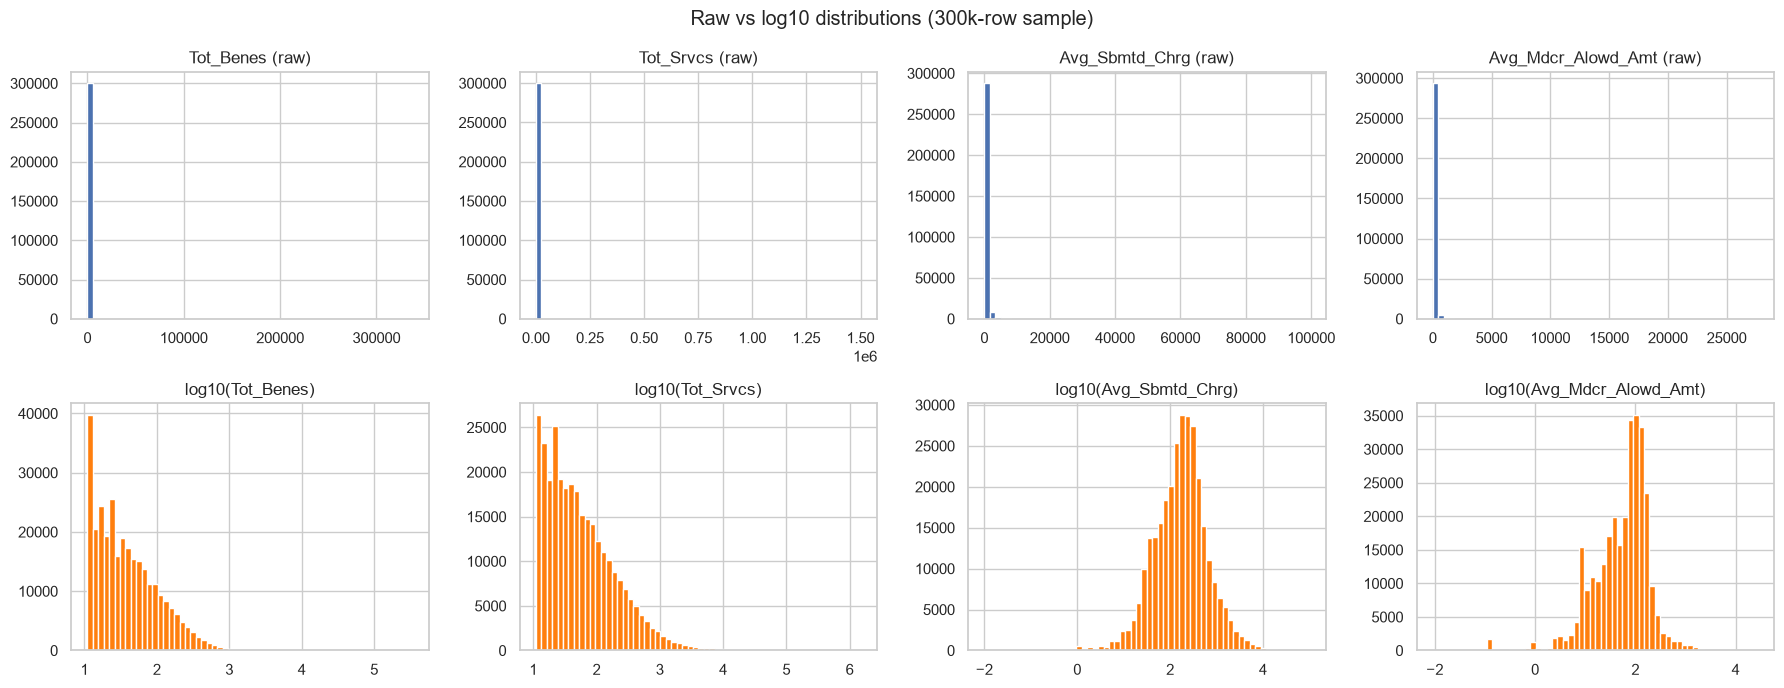

In [21]:
cols = ["Tot_Benes", "Tot_Srvcs", "Avg_Sbmtd_Chrg", "Avg_Mdcr_Alowd_Amt"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, c in enumerate(cols):
    x = s[c]
    axes[0, i].hist(x, bins=60)
    axes[0, i].set_title(f"{c} (raw)")
    axes[1, i].hist(np.log10(x[x > 0]), bins=60, color="tab:orange")
    axes[1, i].set_title(f"log10({c})")
fig.suptitle("Raw vs log10 distributions (300k-row sample)")
savefig("01_distributions")

**Fig 1.** Raw vs log distributions - checking skew

**Notes:**
- Raw data is extremely skewed - need log transform
- Benes/Srvcs start at 11 (CMS privacy cutoff)
- Charges/allowed look normal after log

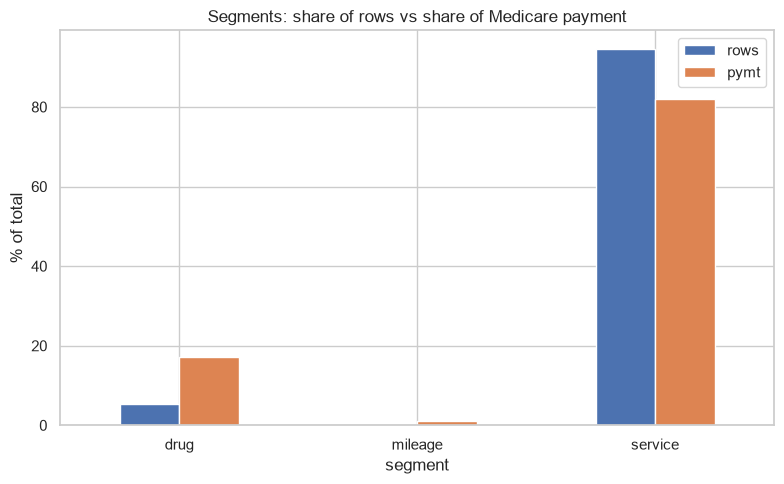

          rows   pymt
segment              
drug      5.41  17.10
mileage   0.10   0.99
service  94.49  81.92


In [22]:
seg = clean.groupby("segment", observed=True).agg(rows=("Rndrng_NPI", "size"),
                                                  pymt=("tot_pymt", "sum"))
seg_pct = seg / seg.sum() * 100
seg_pct.plot.bar(figsize=(8, 5), rot=0)
plt.ylabel("% of total")
plt.title("Segments: share of rows vs share of Medicare payment")
savefig("02_segments")
print(seg_pct.round(2))

**Fig 2.** Segments - how much of the data / money is drug and mileage

**Notes:**
- Drugs: 5% of rows but 17% of money - ~3x more money per row than average
- Mileage: 0.1% of rows, 1% of money - ~10x more per row
- Service: 94% of rows, 82% of money

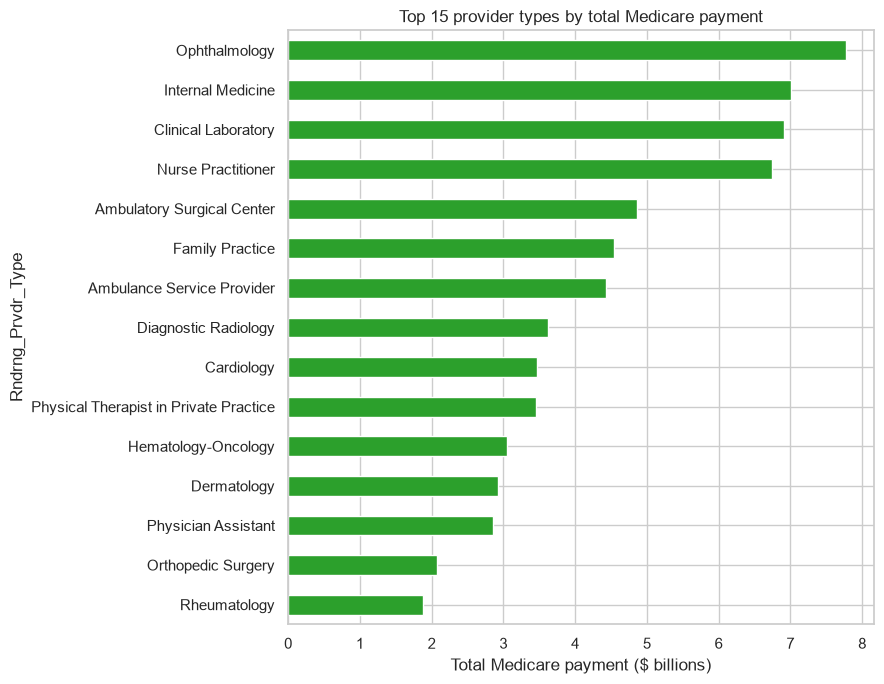

In [24]:
by_type = clean.groupby("Rndrng_Prvdr_Type", observed=True)["tot_pymt"].sum() / 1e9
by_type.nlargest(15).sort_values().plot.barh(figsize=(9, 7), color="tab:green")
plt.xlabel("Total Medicare payment ($ billions)")
plt.title("Top 15 provider types by total Medicare payment")
savefig("03_top_provider_types")

**Fig 3.** Top specialties by total Medicare payment - where the money goes

**Notes:**
- Top: Ophthalmology (~$7.8B), Internal Medicine, Clinical Lab, Nurse Practitioner (~$7B each)
- Mix of individuals and organizations (labs, ambulance, surgical centers) - compare within specialty, not across

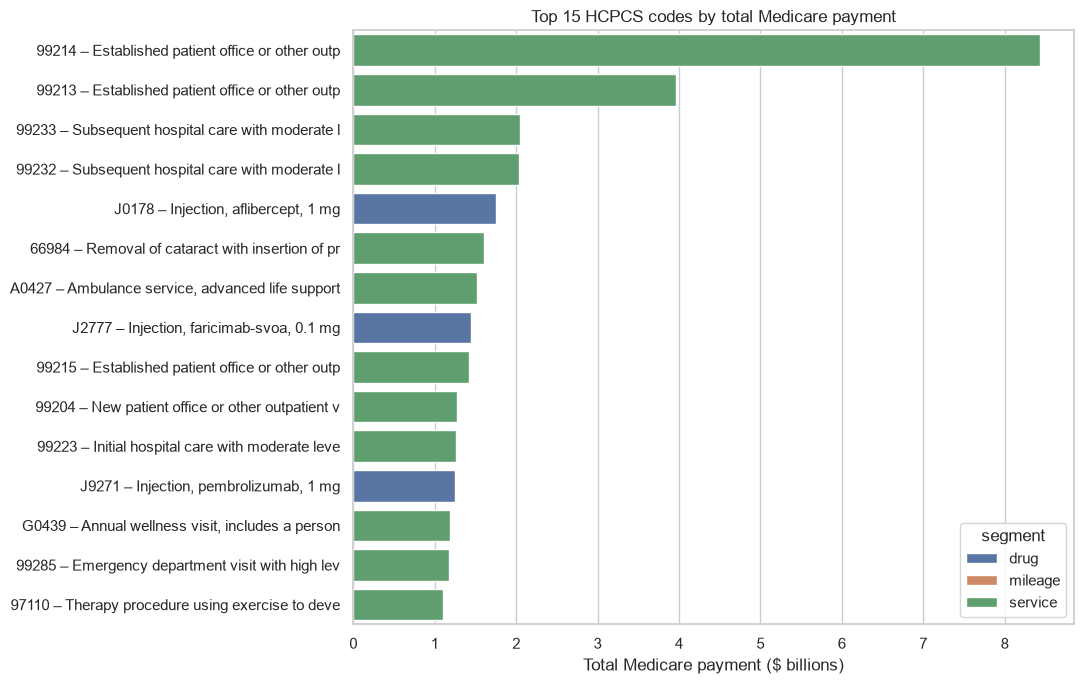

In [25]:
by_code = (clean.groupby(["HCPCS_Cd", "HCPCS_Desc", "segment"], observed=True)["tot_pymt"]
           .sum().div(1e9).nlargest(15).reset_index())
by_code["label"] = by_code["HCPCS_Cd"] + " – " + by_code["HCPCS_Desc"].str[:40]
plt.figure(figsize=(11, 7))
sns.barplot(data=by_code, y="label", x="tot_pymt", hue="segment", dodge=False)
plt.xlabel("Total Medicare payment ($ billions)"); plt.ylabel("")
plt.title("Top 15 HCPCS codes by total Medicare payment")
savefig("04_top_hcpcs")

**Fig 4.** Top procedure codes by total Medicare payment

**Notes:**
- Routine office visits (99214, 99213) = biggest spending by far
- 3 drugs in top 15; 2 are eye injections (J0178, J2777) - explains why ophthalmology is #1 in Fig 3

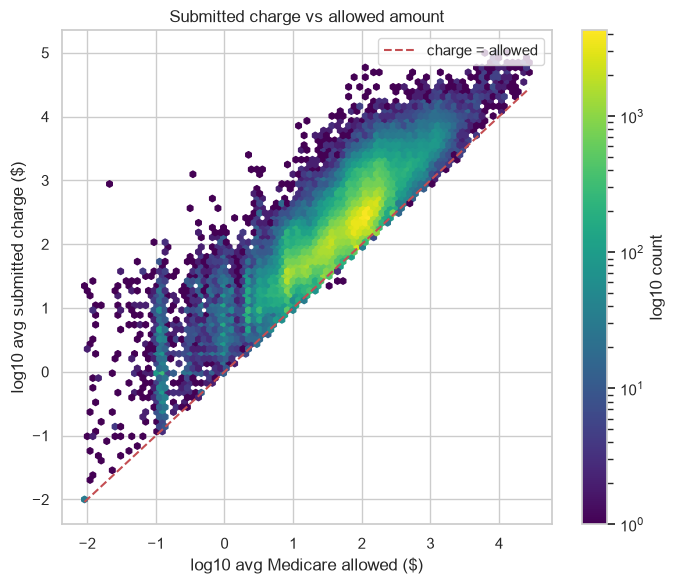

median charge/allowed ratio: 2.98


In [26]:
plt.figure(figsize=(7, 6))
x = np.log10(s["Avg_Mdcr_Alowd_Amt"])
y = np.log10(s["Avg_Sbmtd_Chrg"].clip(lower=1e-4))
plt.hexbin(x, y, gridsize=80, bins="log", cmap="viridis")
lims = [x.min(), x.max()]
plt.plot(lims, lims, "r--", label="charge = allowed")
plt.xlabel("log10 avg Medicare allowed ($)"); plt.ylabel("log10 avg submitted charge ($)")
plt.colorbar(label="log10 count"); plt.legend()
plt.title("Submitted charge vs allowed amount")
savefig("05_charge_vs_allowed")
print("median charge/allowed ratio:", round(clean["chrg_to_alowd"].median(), 2))

**Fig 5.** Charge vs allowed - how much providers bill above what Medicare allows

**Notes:**
- Almost all points above the red line - providers nearly always bill more than Medicare allows
- Strong linear relationship, but big spread above the line - markup varies a lot between providers
- Median charge/allowed ratio = 2.98

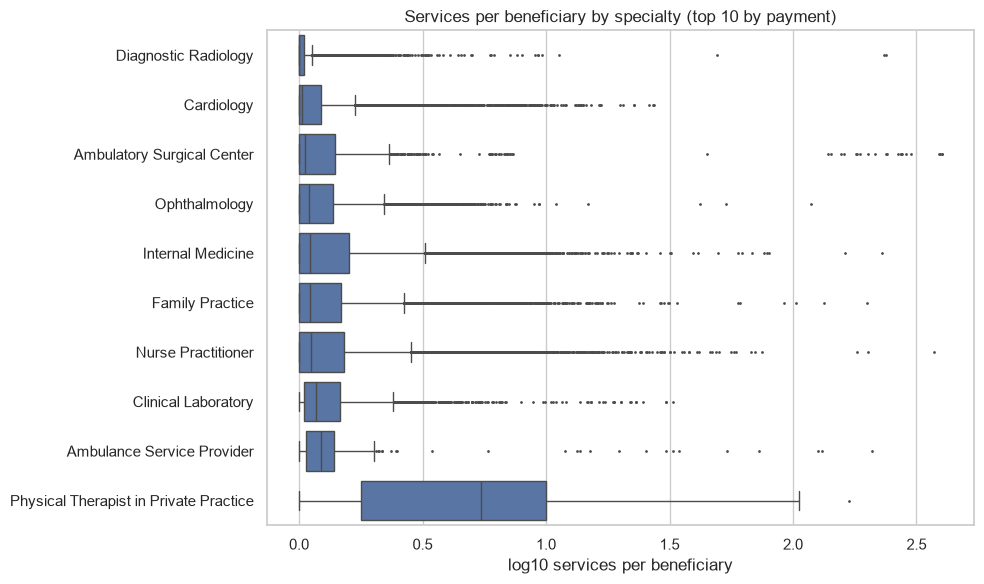

In [27]:
# Top 10 specialties by payment, service segment only (drug units / miles would distort this)
top_types = by_type.nlargest(10).index
sub = s[s["Rndrng_Prvdr_Type"].isin(top_types) & (s["segment"] == "service")].copy()
sub["Rndrng_Prvdr_Type"] = sub["Rndrng_Prvdr_Type"].astype(str)
order = sub.groupby("Rndrng_Prvdr_Type")["srvcs_per_bene"].median().sort_values().index

plt.figure(figsize=(10, 6))
sns.boxplot(data=sub, x=np.log10(sub["srvcs_per_bene"]), y="Rndrng_Prvdr_Type",
            order=order, fliersize=1)
plt.xlabel("log10 services per beneficiary"); plt.ylabel("")
plt.title("Services per beneficiary by specialty (top 10 by payment)")
savefig("06_srvcs_per_bene_by_specialty")

**Fig 6.** Services per patient by specialty - do specialties behave differently? (if yes - need peer groups)

**Notes:**
- Most specialties: ~1–1.5 services per patient
- Physical therapists: ~5–6 per patient (median), way higher - normal for them (many sessions)
- If we compared everyone together, all PTs would look "anomalous" - need peer groups by specialty 
- Long tails in every specialty - outliers exist within each group

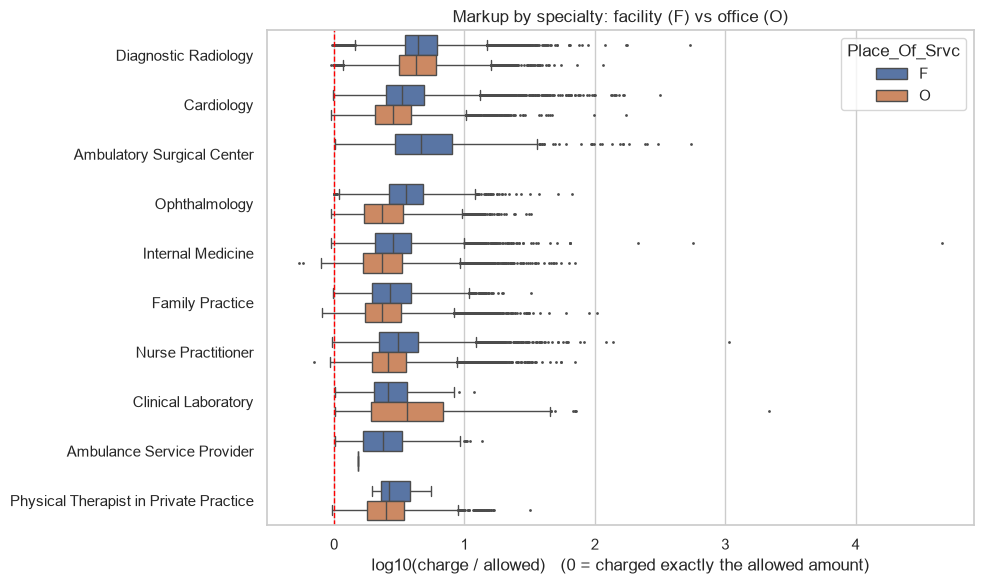

In [28]:
# Uses `sub` and `order` from Fig 6
sub["log_markup"] = np.log10(sub["chrg_to_alowd"])
plt.figure(figsize=(10, 6))
sns.boxplot(data=sub, x="log_markup", y="Rndrng_Prvdr_Type", hue="Place_Of_Srvc",
            order=order, fliersize=1)
plt.axvline(0, color="red", ls="--", lw=1)
plt.xlabel("log10(charge / allowed)   (0 = charged exactly the allowed amount)"); plt.ylabel("")
plt.title("Markup by specialty: facility (F) vs office (O)")
savefig("07_markup_by_specialty_pos")

**Fig 7.** Markup in facility vs office - does place of service matter? (if yes - POS in peer group)

**Notes:**
- Almost everything right of the red line - providers bill ~2.5–4x the allowed amount (log10 ≈ 0.4–0.6)
- For most doctors, facility (F) markup > office (O) markup (e.g. Ophthalmology: F ≈ 3.5x vs O ≈ 2.4x)
- Some specialties exist only in one setting (Surgical Centers, Ambulance - F)
- Same specialty has different markup in F vs O - compare office rows only with office rows, facility only with facility (place of service in peer groups) 

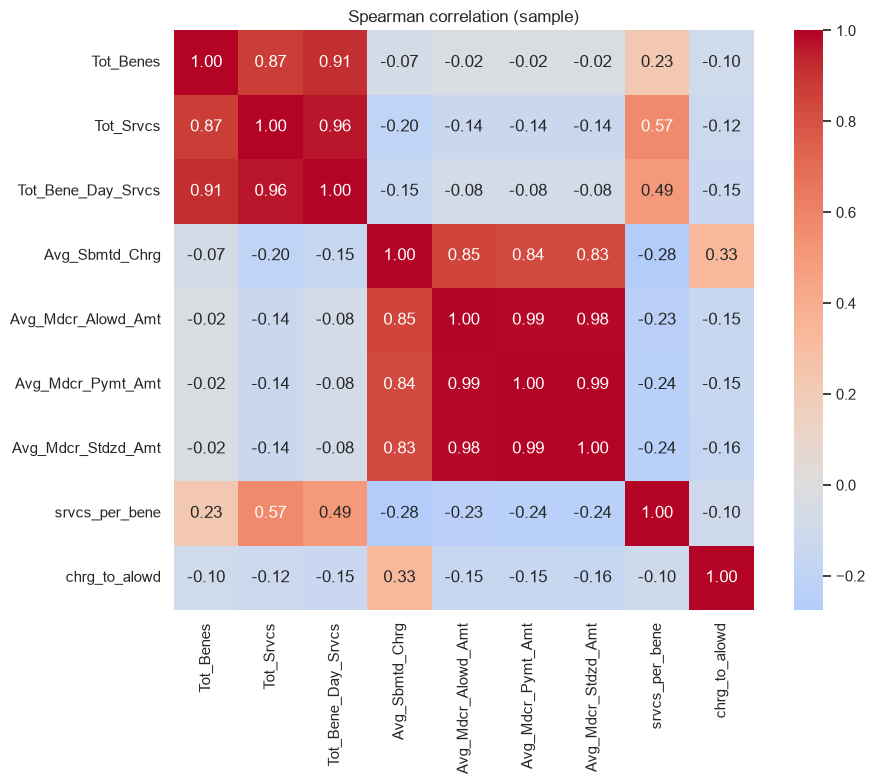

In [29]:
# Spearman = rank-based, robust to skew
corr_cols = ["Tot_Benes", "Tot_Srvcs", "Tot_Bene_Day_Srvcs", "Avg_Sbmtd_Chrg",
             "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt", "Avg_Mdcr_Stdzd_Amt",
             "srvcs_per_bene", "chrg_to_alowd"]
plt.figure(figsize=(10, 8))
sns.heatmap(s[corr_cols].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Spearman correlation (sample)")
savefig("08_correlation")

**Fig 8.** Correlations - which columns duplicate each other

**Notes:**
- 2 blocks of near-duplicate columns:
  - Volume: Benes / Srvcs / Bene_Days (0.87–0.96)
  - Money: Alowd / Pymt / Stdzd (0.98–0.99) - keep just Stdzd for the model
- Volume and price barely related (~0 to -0.2)
- Ratios (srvcs_per_bene, chrg_to_alowd) weakly correlated with raw columns - add new info, good features 

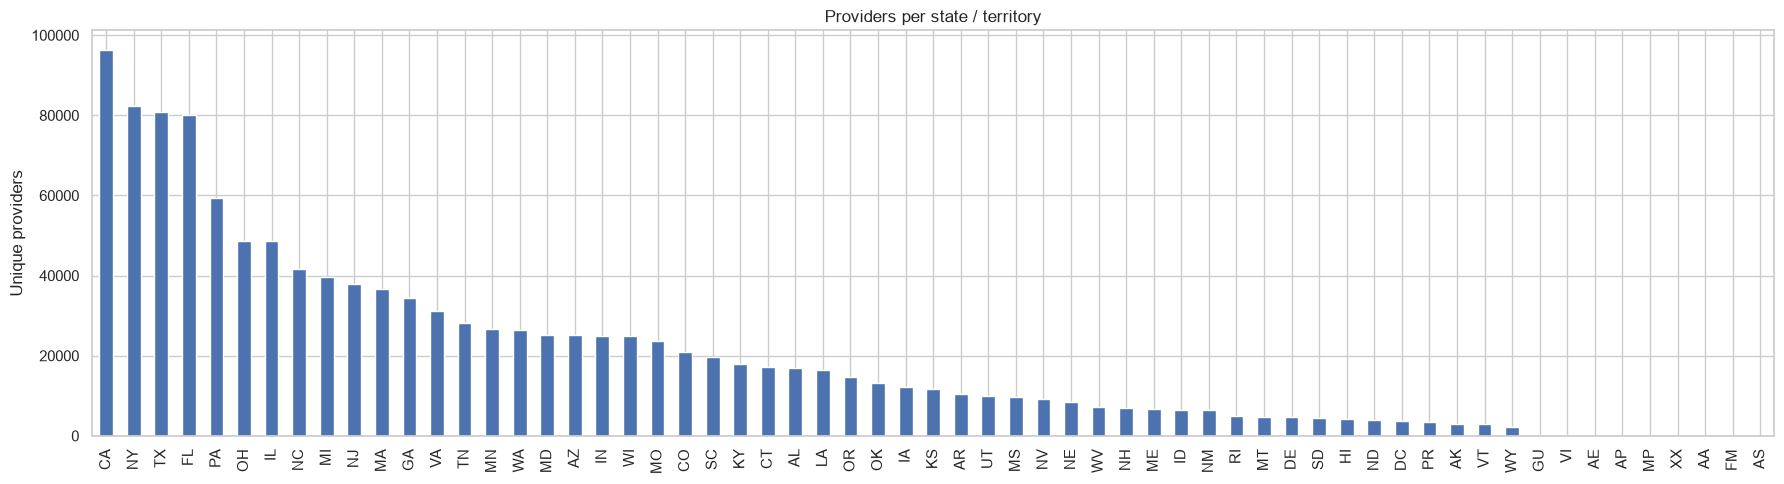

In [31]:
prov_state = (clean.groupby("Rndrng_Prvdr_State_Abrvtn", observed=True)["Rndrng_NPI"]
              .nunique().sort_values(ascending=False))
prov_state.plot.bar(figsize=(18, 5))
plt.ylabel("Unique providers"); plt.xlabel("")
plt.title("Providers per state / territory")
savefig("09_providers_per_state")

**Fig 9.** Providers per state - geography overview, base for Power BI map

**Notes:**
- Largest states have the most providers (CA, NY, TX, FL)
- Territories and military codes (GU, VI, AE, AP, MP, AA, FM, AS) - very few providers
- `XX` = unknown state - tiny, check count

In [32]:
(clean["Rndrng_Prvdr_State_Abrvtn"] == "XX").sum()

np.int64(258)

- `XX` = unknown state, 258 rows (0.003%) - keep, just won't show on the map

### Output tables
Split `clean` into model input + 2 lookup tables for Power BI (star schema). See `DATA_MODEL.md`.
- `ml_table` - model (no names/addresses)
- `dim_provider` - 1 row per NPI (name, location, specialty)
- `dim_hcpcs` - 1 row per procedure code

In [33]:
# Single integer key for each row (NPI x HCPCS x POS)
clean["row_id"] = np.arange(len(clean))

# Model input: keys, peer-group columns, numeric billing variables
ml_cols = ["row_id", "Rndrng_NPI", "HCPCS_Cd", "Place_Of_Srvc",
           "Rndrng_Prvdr_Type", "segment", "Rndrng_Prvdr_Ent_Cd", "HCPCS_Drug_Ind",
           "Rndrng_Prvdr_Mdcr_Prtcptg_Ind", "Rndrng_Prvdr_RUCA",
           "Tot_Benes", "Tot_Srvcs", "Tot_Bene_Day_Srvcs",
           "Avg_Sbmtd_Chrg", "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt", "Avg_Mdcr_Stdzd_Amt"]
ml_table = clean[ml_cols]

# Power BI: one row per provider
prov_cols = ["Rndrng_NPI", "Rndrng_Prvdr_Last_Org_Name", "Rndrng_Prvdr_First_Name",
             "Rndrng_Prvdr_Crdntls", "Rndrng_Prvdr_Ent_Cd", "Rndrng_Prvdr_City",
             "Rndrng_Prvdr_State_Abrvtn", "Rndrng_Prvdr_Zip5", "Rndrng_Prvdr_RUCA",
             "Rndrng_Prvdr_RUCA_Desc", "Rndrng_Prvdr_Type"]
# Check provider info is the same in every row of an NPI (should all be 1)
print(clean.groupby("Rndrng_NPI")[prov_cols[1:]].nunique().max(), "\n")
dim_provider = clean[prov_cols].drop_duplicates("Rndrng_NPI")

# Power BI: one row per procedure code
dim_hcpcs = clean[["HCPCS_Cd", "HCPCS_Desc", "HCPCS_Drug_Ind", "segment"]].drop_duplicates("HCPCS_Cd")

# Keys must be unique
assert dim_provider["Rndrng_NPI"].is_unique
assert dim_hcpcs["HCPCS_Cd"].is_unique

# Save
os.makedirs("data/processed", exist_ok=True)
clean.to_parquet("data/processed/medicare_2024_clean.parquet", index=False)
ml_table.to_parquet("data/processed/ml_table.parquet", index=False)
dim_provider.to_parquet("data/processed/dim_provider.parquet", index=False)
dim_hcpcs.to_parquet("data/processed/dim_hcpcs.parquet", index=False)

print("ml_table:    ", ml_table.shape)
print("dim_provider:", dim_provider.shape)
print("dim_hcpcs:   ", dim_hcpcs.shape)

Rndrng_Prvdr_Last_Org_Name    1
Rndrng_Prvdr_First_Name       1
Rndrng_Prvdr_Crdntls          1
Rndrng_Prvdr_Ent_Cd           1
Rndrng_Prvdr_City             1
Rndrng_Prvdr_State_Abrvtn     1
Rndrng_Prvdr_Zip5             1
Rndrng_Prvdr_RUCA             1
Rndrng_Prvdr_RUCA_Desc        1
Rndrng_Prvdr_Type             1
dtype: int64 

ml_table:     (9781161, 17)
dim_provider: (1207397, 11)
dim_hcpcs:    (6471, 4)
